In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

In [26]:
df = pd.read_csv("cleaned_dataset.csv")
print(df.shape)
df.head()

(927049, 18)


,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_capped,amount_bin,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_cash
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,Medium,False,False,False,True,False,0
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,Medium,False,False,False,True,False,0
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,Small,False,False,False,False,True,0
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,Small,False,True,False,False,False,1
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,Medium,False,False,False,True,False,0


In [4]:
print("Unique transaction types:", df['type'].unique())
print(df['type'].value_counts())

Unique transaction types: ['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']
type
CASH_OUT    336912
PAYMENT     304235
CASH_IN     203430
TRANSFER     76513
DEBIT         5959
Name: count, dtype: int64


In [5]:
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=False)
df_encoded.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_capped,amount_bin,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,Medium,False,False,False,True,False
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,Medium,False,False,False,True,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,Small,False,False,False,False,True
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,Small,False,True,False,False,False
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,Medium,False,False,False,True,False


In [8]:
df_encoded['is_cash'] = df_encoded[['type_CASH_IN', 'type_CASH_OUT']].sum(axis=1)
df_encoded['is_cash'] = df_encoded['is_cash'].apply(lambda x: 1 if x > 0 else 0)


In [9]:
print(df_encoded[['is_cash']].head())
print(df_encoded.shape)

   is_cash
0        0
1        0
2        0
3        1
4        0
(927049, 18)


In [10]:
corr_cols = [col for col in df_encoded.columns if "type_" in col] + ['is_cash', 'isFraud']
corr = df_encoded[corr_cols].corr()

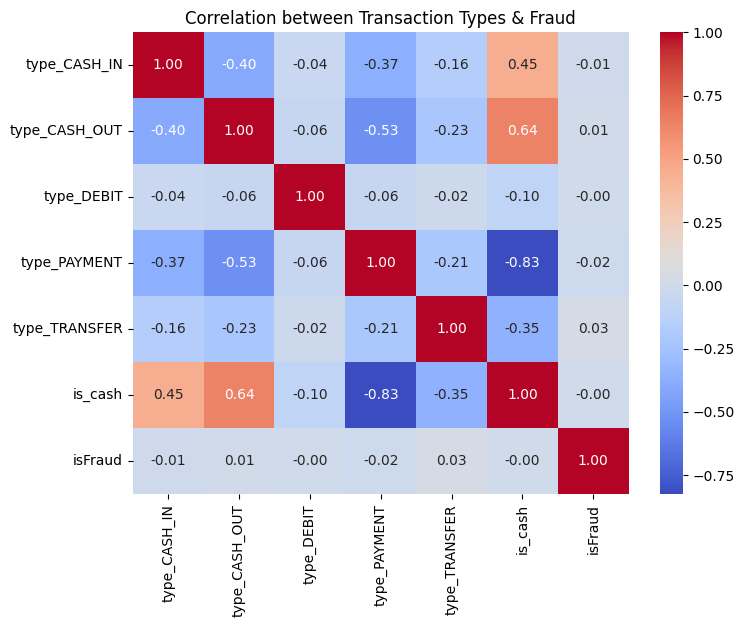

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Transaction Types & Fraud")
plt.show()

In [12]:
df_encoded.to_csv("cleaned_dataset.csv", index=False)

In [14]:
from google.colab import files
files.download("cleaned_dataset.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>